Saving HousingData.csv to HousingData (2).csv
MSE: 24.999384790103367
RMSE: 4.999938478631849
R2 Score: 0.659101389390351
Train R2: 0.742578124156171
Test R2: 0.659101389390351

Feature Importance:
          Coefficient
RM          3.311067
RAD         1.898193
B           1.097459
CHAS        0.821042
ZN          0.648192
INDUS      -0.171845
AGE        -0.499493
CRIM       -0.963899
TAX        -1.524501
NOX        -1.849702
PTRATIO    -1.924917
LSTAT      -3.113734
DIS        -3.168525


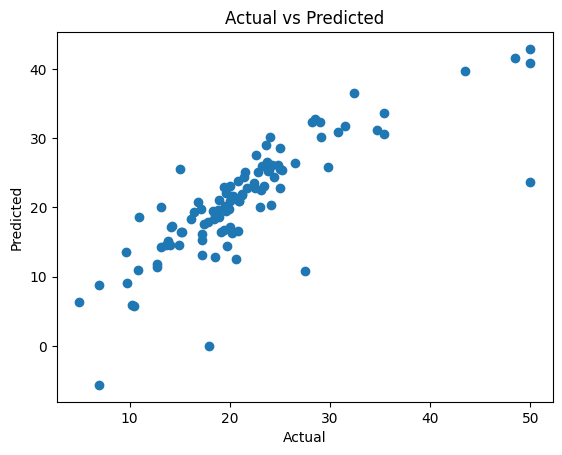

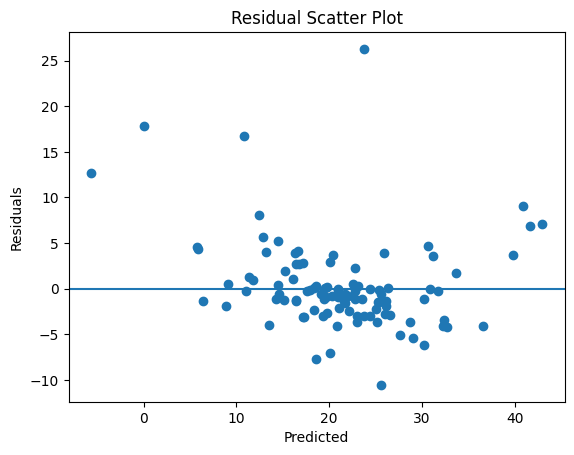

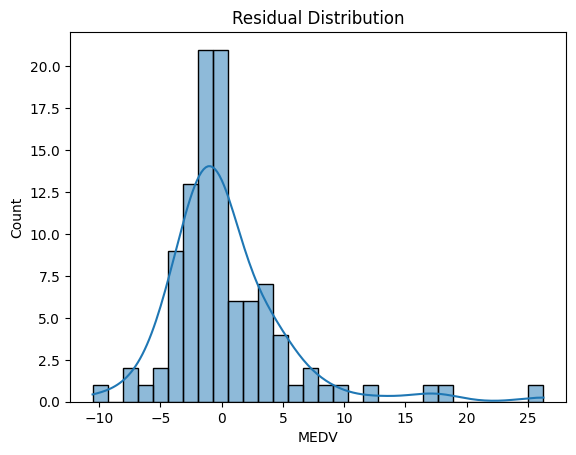

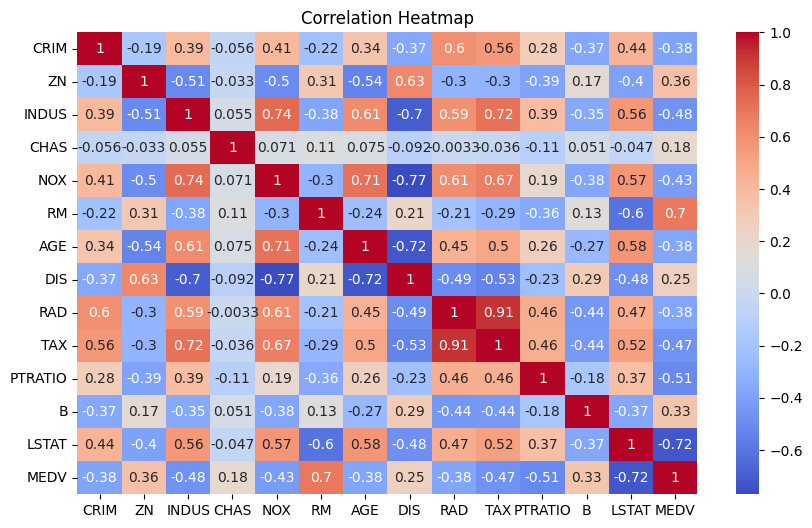

In [5]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

#upload file
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv("HousingData.csv")

# Handle missing values
df.fillna(df.median(), inplace=True)

# Features and target
X = df.drop('MEDV', axis=1)
y = df['MEDV']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# Train score vs Test score (Overfitting check)
print("Train R2:", model.score(X_train, y_train))
print("Test R2:", model.score(X_test, y_test))

# Coefficients (Feature Importance)
coeff_df = pd.DataFrame(model.coef_, df.columns[:-1], columns=['Coefficient'])
coeff_df = coeff_df.sort_values(by='Coefficient', ascending=False)
print("\nFeature Importance:\n", coeff_df)

# Visualizations

# 1. Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

# 2. Residual Scatter Plot (IMPORTANT)
plt.figure()
plt.scatter(y_pred, y_test - y_pred)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Scatter Plot")
plt.axhline(y=0)
plt.show()

# 3. Residual Distribution
plt.figure()
sns.histplot(y_test - y_pred, bins=30, kde=True)
plt.title("Residual Distribution")
plt.show()

# 4. Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
